# High-Frequency Sleep Staging: Downstream Task Performance

This notebook creates publication figures showing how downstream task performance
varies with the temporal resolution of sleep stage predictions.

## Panels

1. **ISRUC Age Prediction** (left)
   - Task: Predict subject age from sleep stage transition patterns
   - Metric: RMSE (lower is better)
   - Baseline: Predicting mean age for all subjects

2. **ISRUC Sex Classification** (middle)
   - Task: Classify subject sex from sleep stage transition patterns
   - Metric: Macro F1 (higher is better)
   - Baseline: Random guessing (≈0.5 MF1)

3. **DODO vs DODH Device Classification** (right)
   - Task: Identify recording device from sleep patterns
   - Metric: Macro F1 (higher is better)
   - Baseline: Random guessing (≈0.5 MF1)

## Data Flow

```
predict-high-freq.py sweeps (logs/exp002/exp002a/sweep-*/)
        ↓
scripts/high-freq/anysleep_isruc_*.ipynb (feature extraction + random forest CV)
        ↓
scripts/final-figures/hf_scores.py (pre-computed scores)
        ↓
This notebook (visualization)
```

## Output

- `high-freq-panels.svg`: Three-panel figure for publication

## Dependencies

- `hf_scores.py`: Pre-computed RMSE/MF1 scores from downstream task experiments
- `isruc-info/*.xlsx`: ISRUC dataset metadata (age, sex) for baseline computation

In [1]:
import numpy as np
from matplotlib import pyplot as plt

from hf_scores import mnc_nt1_vs_hc, dodo_vs_dodh, cap_n_vs_ins

DODO vs DODH: [0.62907349 0.69033307 0.67342626 0.64556419 0.73090466 0.72792164
 0.79652217 0.89430991 0.90605732 0.88654404 0.8904269  0.86953901
 0.84200573 0.82151951]
MNC NT1: [0.70932293 0.74104714 0.79282963 0.82753244 0.83130513 0.84073675
 0.8536917  0.8594742  0.85750999 0.85180985 0.84717332 0.83575694
 0.82398141 0.82956925]
CAP insomnia: [0.62263438 0.55196124 0.60235251 0.67286389 0.77159883 0.81615877
 0.79267971 0.79772581 0.77483687 0.75759765 0.7815082  0.790937
 0.75562124 0.72188578]


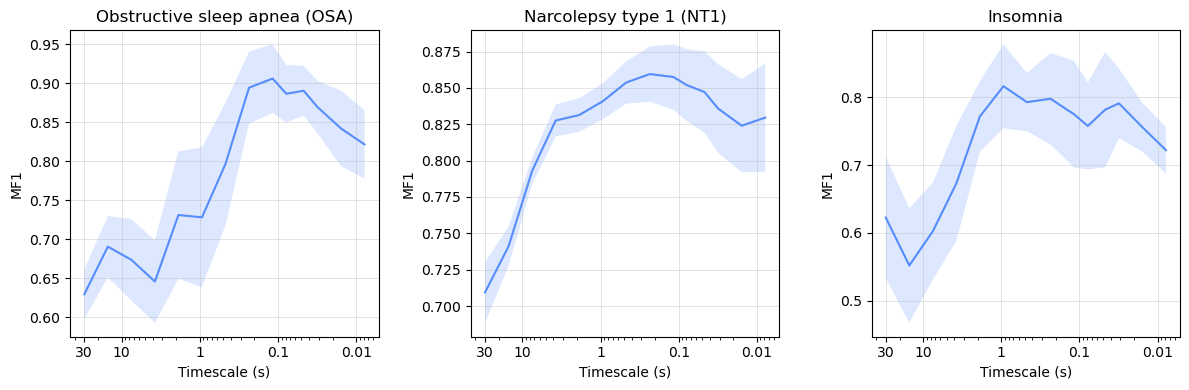

In [2]:
_, axes = plt.subplots(1, 3, figsize=(12, 4))
axes = axes.flatten()

# panel DODO vs DODH
scores_to_plot = {}
for i, (model_run, mf1_scores_model) in enumerate(dodo_vs_dodh.items()):
    for sr in mf1_scores_model.keys():
        if sr not in scores_to_plot:
            scores_to_plot[sr] = []
        scores_to_plot[sr].append(mf1_scores_model[sr])

scores_to_plot = {sr: np.array(v) for sr, v in scores_to_plot.items()}
means_to_plot = np.array([np.mean(v) for v in scores_to_plot.values()])
x_axis = [30 / k for k in scores_to_plot.keys()]
print(f"DODO vs DODH: {means_to_plot}")
stds_to_plot = np.array([np.std(v) for v in scores_to_plot.values()])
axes[0].plot(x_axis, means_to_plot)
axes[0].fill_between(x_axis, means_to_plot - stds_to_plot, means_to_plot + stds_to_plot, alpha=0.2)

axes[0].set_title("Obstructive sleep apnea (OSA)")

# panel MNC Nt1 vs Healthy
scores_to_plot = {}
for i, (model_run, f1s_model) in enumerate(mnc_nt1_vs_hc.items()):
    for sr in f1s_model.keys():
        if sr not in scores_to_plot:
            scores_to_plot[sr] = []
        scores_to_plot[sr].append(f1s_model[sr])

scores_to_plot = {sr: np.array(v) for sr, v in scores_to_plot.items()}
means_to_plot = np.array([np.mean(v) for v in scores_to_plot.values()])
print(f"MNC NT1: {means_to_plot}")
stds_to_plot = np.array([np.std(v) for v in scores_to_plot.values()])
axes[1].plot(x_axis, means_to_plot)
axes[1].fill_between(x_axis, means_to_plot - stds_to_plot, means_to_plot + stds_to_plot, alpha=0.2)

axes[1].set_title("Narcolepsy type 1 (NT1)")

# panel CAP insomnia prediction
scores_to_plot = {}
for i, (model_run, mf1_scores_model) in enumerate(cap_n_vs_ins.items()):
    for sr in mf1_scores_model.keys():
        if sr not in scores_to_plot:
            scores_to_plot[sr] = []
        scores_to_plot[sr].append(mf1_scores_model[sr])

scores_to_plot = {sr: np.array(v) for sr, v in scores_to_plot.items()}
means_to_plot = np.array([np.mean(v) for v in scores_to_plot.values()])
print(f"CAP insomnia: {means_to_plot}")
stds_to_plot = np.array([np.std(v) for v in scores_to_plot.values()])
axes[2].plot(x_axis, means_to_plot)
axes[2].fill_between(x_axis, means_to_plot - stds_to_plot, means_to_plot + stds_to_plot, alpha=0.2)

axes[2].set_title("Insomnia")

for ax in axes:
    ax.set_xscale("log")
    ax.set_xticks([1e-2, 1e-1, 1, 10, 30], [1e-2, 1e-1, 1, 10, 30])
    ax.grid(axis="x")
    ax.set_xlabel("Timescale (s)")
    ax.set_ylabel("MF1")
    # flip x axis
    ax.invert_xaxis()
    ax.tick_params(
        axis='both',
        which='both',
        bottom=True,
        top=False,
        left=True, )
    ax.grid(axis="y")

plt.tight_layout()
plt.subplots_adjust(wspace=0.3)
plt.savefig("fig_3.svg", bbox_inches="tight")
plt.show()